# Exercises for Section 2.7 Simulation and empirical distributions

This notebook contains the exercises from [Section 2.7 Simulation and empirical distributions](https://minireference.com/static/excerpts/noBSstats_part1_preview.pdf#page=81) of the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Figures setup
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={'figure.figsize': (5,2)},
)
%config InlineBackend.figure_format = 'retina'

In [3]:
# Simple float __repr__
import numpy as np
if int(np.__version__.split(".")[0]) >= 2:
    np.set_printoptions(legacy='1.25')

## Exercies

### E2.50

Recall the random variable $H \sim \mathrm{Pois}(\lambda\!=\!20)$
that describes the number of hard disk failures in a data centre.
In Section 2.1,
we created a computer model `rvH = poisson(20)`
and used this model to answer various business questions.
Suppose you have a list `hs = rvH.rvs(5000)`
that contains $5000$ random observations from $H$.
Let's revisit the questions and answer them using the list `hs`.

**a)** Plot the empirical PMF $f_{\texttt{hs}}$ and the PMF $f_H$.

**b)** Find the probability of the event $\{ 15 \leq H \leq 20 \}$ from the list.

**c)** Estimate the location of the $0.95$ quantile of $H$.

**d)** Generate 12 bootstrap observations from the list `hs`.

**e)** Compute the expected value of the function `cost` defined in the book.

Compare the approximate answers you obtain from the list `hs`
to the values we obtained earlier in Section 2.1

Hint: For part **d)**,
recall that "bootstrap observation from `xs`"
are obtained by sampling with replacement within the list `xs`.

In [4]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(45)

# Create the computer model rvH
from scipy.stats import poisson
rvH = poisson(20)

# Generate 5000 random observations from rvH
hs = rvH.rvs(5000)

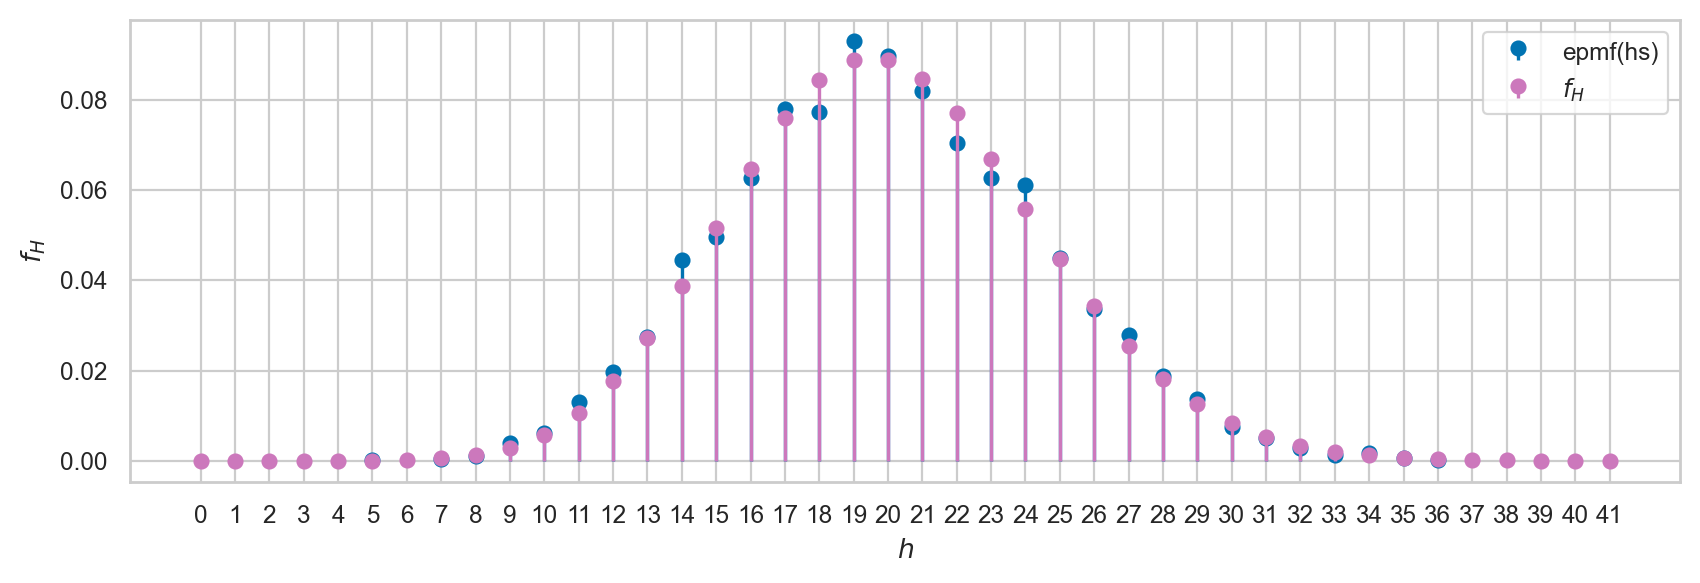

In [5]:
# a)
from ministats import plot_epmf, plot_pmf

plt.figure(figsize=(10,3))
ax = plot_epmf(hs, ax=plt.gca(), name="hs")
plot_pmf(rvH, ax=ax, rv_name="H", label="$f_H$", color="C4");

In [6]:
# b) Probability of the event {15 ≤ H ≤ 20}
len([h for h in hs if 15<=h<=20]) / len(hs)

0.4498

In [7]:
# b) Exact value of Pr({15 ≤ H ≤ 20})
sum([rvH.pmf(h) for h in range(15,20+1)])

0.45422830312333884

In [8]:
# c)
np.quantile(hs, 0.95)

28.0

In [9]:
# c) exact value
rvH.ppf(0.95)

28.0

In [10]:
# d) Generate random observations
# Set the random seed to a particular value to get a reproducible result
np.random.seed(46)

# Generate 12 random observations from the r.v. H
np.random.choice(hs, size=12, replace=True)

array([29, 20, 17, 16, 13, 16, 30, 16, 10, 20, 17, 12])

In [12]:
# e)
# Define the cost function
def cost(h):
    if h >= 20:
        return 150*h
    else:
        return 200*h

# Compute the expected value of `cost` for r.v. H using `hs`
sum([cost(h) for h in hs]) / len(hs)

3373.82

In [13]:
# e) exact value
rvH.expect(np.vectorize(cost))

3381.42194944714

### E2.51

Recall the random variable $K \sim \mathcal{N}(\mu_K\!=\!1000, \sigma_K\!=\!10)$
that describes the kombucha volumes at the bottling plant.
In this exercise,
you'll use a list `ks` that contains $N=10\,000$ random observations from $K$
to answer the following probability questions.

**a)** Plot a histogram of the values in the list `ks` and the PDF $f_K$.

**b)** Plot the empirical CDF of `ks` and the CDF $F_K$.

**c)** Find the probability of the event $\{ 980 \leq K \leq 1020 \}$ from the list.

**d)** Estimate the location of the first quartile of $K$.

**e)** Compute a 90% central probability interval for $K$.

**f)** Compute the expected value of the function `payment`
defined in the book.

Compare the approximate answers you obtain to the exact values
that we obtained earlier in Example 3 in Section 2.4.

Hint: Use `rvK.rvs(10000)` to obtain the list `ks`.

In [15]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(45)

# Create the computer model rvK
from scipy.stats import norm
rvK = norm(1000, 10)

# Generate 10000 random observations from rvK
ks = rvK.rvs(10000)

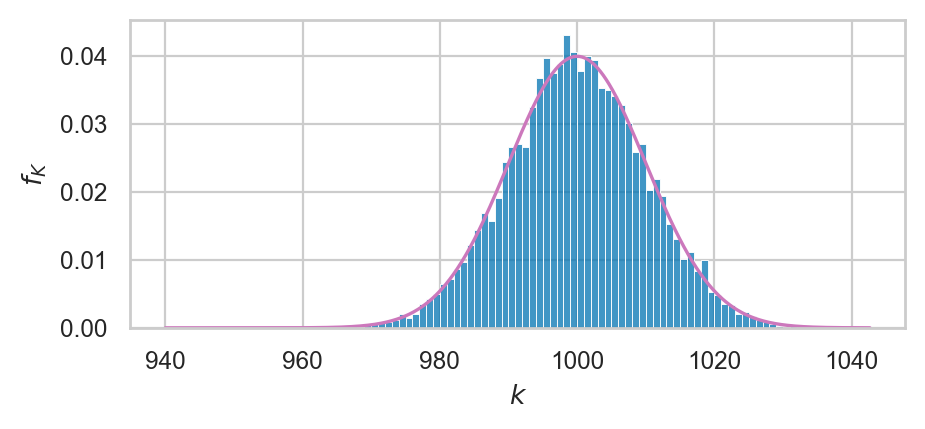

In [16]:
# a)
import seaborn as sns
from ministats import plot_pdf

bins = range(960, 1040)
ax = sns.histplot(x=ks, stat="density", bins=bins)
plot_pdf(rvK, ax=ax, rv_name="K", color="C4");

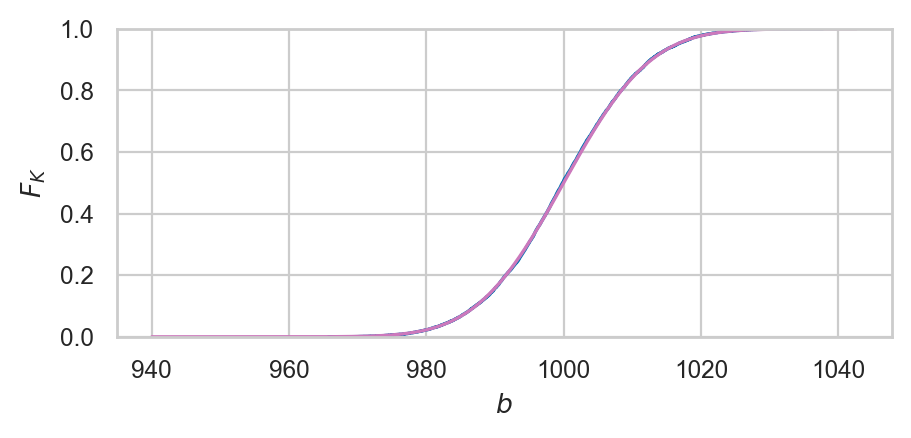

In [17]:
# b)
from ministats import plot_cdf

ax = sns.ecdfplot(x=ks)
plot_cdf(rvK, ax=ax, rv_name="K", color="C4");

In [18]:
# c)
len([k for k in ks if 980<=k<=1020]) / len(ks)

0.9555

In [19]:
# c) exact value
from scipy.integrate import quad
quad(rvK.pdf, a=980, b=1020)[0]

0.9544997361036411

In [20]:
# d)
np.quantile(ks, 0.25)

993.4334734844825

In [21]:
# d) exact value
rvK.ppf(0.25)

993.2551024980392

In [22]:
# e)
np.quantile(ks, [0.05, 0.95])

array([ 983.47843998, 1016.58315384])

In [23]:
# e) exact value
[rvK.ppf(0.05), rvK.ppf(0.95)]

[983.5514637304852, 1016.4485362695148]

In [25]:
# f)

# Define the payment function
def payment(k):
    if 980 <= k and k <= 1020:
        return 2
    else:
        return 0

# Compute the expected value of `payment` for r.v. K using `ks`
sum([payment(k) for k in ks]) / len(ks)

1.911

In [26]:
# f) exact value
rvK.expect(payment)

1.9089994604952036

### E2.52

The cumulative distribution function of the random variable $E \sim \mathrm{Expon}(\lambda)$
is $F_E(b) = 1 - e^{-\lambda b}$, for $b \geq 0$.
Find the math expression for the inverse cumulative distribution function $F_E^{-1}(q)$.

Hint:
Start with the equation $q = 1 - e^{-\lambda b}$ and solve for $b$.

<!-- solution -->
We start with the cumulative distribution function
$F_E(b) = 1 - e^{-\lambda b}$,
and define a new variable $q$ to describe the output of the function $F_E$ when the input is $b$:
$q = F_E(b)$.
To find the inverse function $F_E^{-1}$,
we need to solve for $b$ in the equation $q = 1 - e^{-\lambda b}$.
After some basic rearrangement we get $e^{-\lambda b} = 1 - q$,
taking the logarithm of both sides we get $-\lambda b = \ln( 1- q )$,
then after some simplification,
we get $F_E^{-1}(q) = b = - \tfrac{ \ln( 1- q ) }{ \lambda }$,
which is the formula for the inverse of the cumulative distribution.

### E2.53

The `random` module provides the function `random.random()`
for generating observations
from the standard uniform distribution $U \sim \mathcal{U}(\alpha\!=\!0,\beta\!=\!1)$.
Let's test the quality of the random numbers produced by this function
by generating a list `us` of $N=600$ random numbers
and comparing them to the model $\texttt{rvU = uniform(0,1)}$.

**a)** Plot a histogram of the observations `us` and the PDF $f_U$.

**b)** Inspect the empirical CDF $F_{\texttt{us}}$ and the CDF $F_U$ visually.

**c)** Generate a Q-Q plot of `us` versus $U$.

**d)** Compute the mean, the variance, the skew, and the excess kurtosis of the data `us`
and compare them to the properties of $U \sim \mathcal{U}(0,1)$.

**e)** Compute the Kolmogorov--Smirnov distance $D_{\textrm{KS}}(\texttt{us},U)$.



In [28]:
import random

# Set the random seed to a particular value to get a reproducible result
random.seed(47)

# Generate one observation from `random.random()`
import random
random.random()

0.35184625582788265

In [29]:
import random

# Set the random seed to a particular value to get a reproducible result
random.seed(47)

# Generate 600 observations using random.random()
us = [random.random() for i in range(600)]
us[0:5]  # first five observations

[0.35184625582788265,
 0.430186245990098,
 0.4536708635895742,
 0.3434697408782532,
 0.5124443649244089]

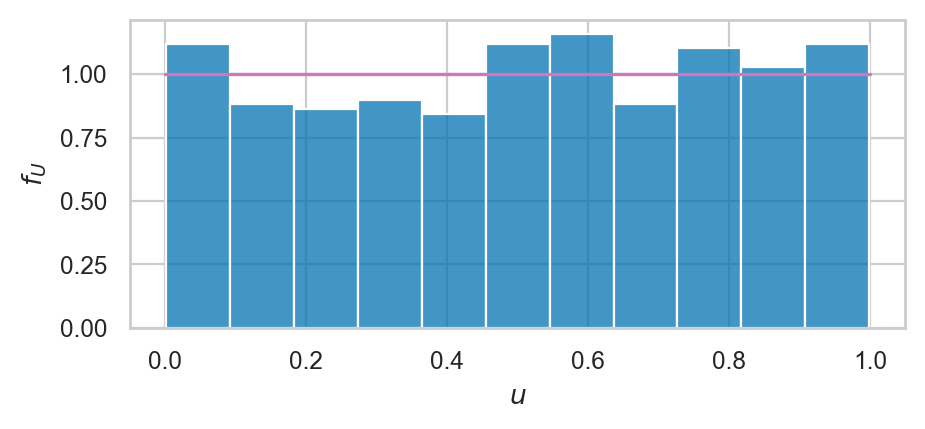

In [30]:
# a) Plot histogram of `us` and the PDF of rvU
import seaborn as sns
ax = sns.histplot(x=us, stat="density")

from scipy.stats import uniform
rvU = uniform(0,1)
from ministats import plot_pdf
plot_pdf(rvU, ax=ax, rv_name="U", color="C4");

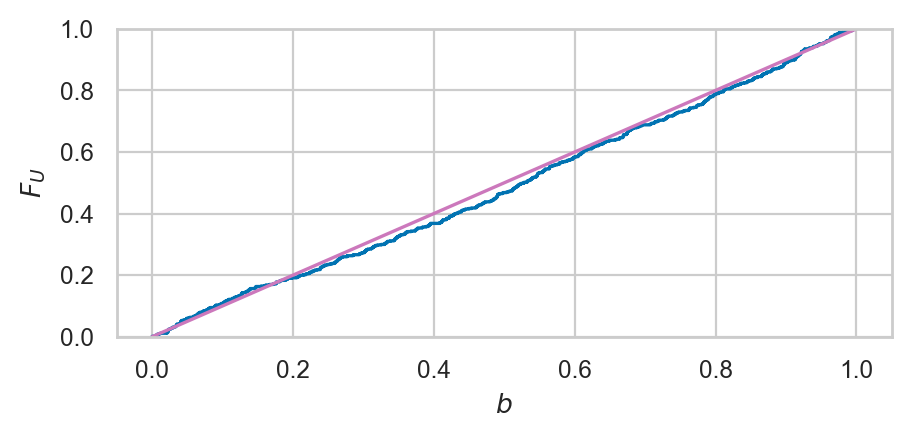

In [31]:
# b) Inspect the empirical CDF of the `us` and the CDF of `rvU`

# Plot the eCDF of the `us`
ax = sns.ecdfplot(x=us)

# Plot the CDF of `rvU`
from ministats import plot_cdf
plot_cdf(rvU, ax=ax, rv_name="U", color="C4");

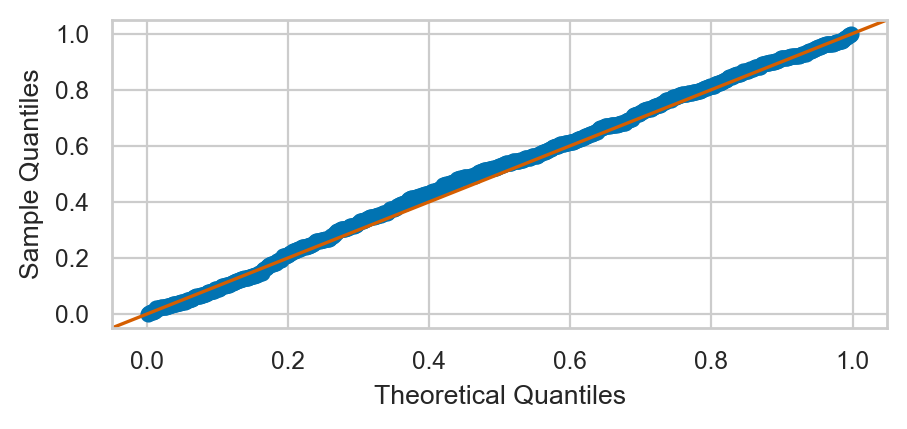

In [32]:
# c) Generate a Q-Q plot of the `us` versus `rvU`

# Wrap the data `us` as a NumPy array
us_array = np.array(us)

# Generate the Q-Q plot
import statsmodels.api as sm
sm.qqplot(us_array, rvU, line="45");

In [33]:
# d) Compare the variance, the skew, and the kurtosis of the `us` and `rvU`

# Wrap the data `us` as a pandas series object
us_series = pd.Series(us)

# Compare the mean of the `us` and `rvU`
us_series.mean(), rvU.mean()

(0.5135832191650309, 0.5)

In [34]:
# d) Compare the variance of the `us` and `rvU`
us_series.var(),  rvU.var()

(0.0846487789841045, 0.08333333333333333)

In [35]:
# d) Compare the skew of the `us` and `rvU`
us_series.skew(), rvU.stats("s")

(-0.10282980248036674, 0.0)

In [36]:
# d) Compare the kurtosis of the `us` and `rvU`
us_series.kurt(), rvU.stats("k")

(-1.1795793838312343, -1.2)

In [37]:
# e) Compute the Kolmogorov--Smirnov distance between `us` and `rvU`
from scipy.stats import ks_1samp
ks_1samp(us, rvU.cdf).statistic

0.04155277761710846

### E2.54

Use the random numbers generated by `random.random()`
and the inverse CDF trick
to generate $N=1000$ random observations from the uniform random variable
$V \sim \mathcal{U}(\alpha\!=\!100,\beta\!=\!120)$.

**a)** Plot a histogram of the observations `vs` and the PDF $f_V$.

**b)** Plot the empirical CDF $F_{\texttt{vs}}$ and the CDF $F_V$.

**c)** Generate a Q-Q plot of `vs` versus $V$.

**d)** Compute the mean, the variance, the skew, and the excess kurtosis of the data `vs`
and compare them to the properties of $V$.

**e)** Compute the Kolmogorov--Smirnov distance $D_{\textrm{KS}}(\texttt{vs},V)$.

Hint:
Find the formula for the CDF $F_V(b)$
and invert it to get $F^{-1}_V(q)$.

Hint:
Use `rvV=uniform(100,20)` to create a computer model for $V$.

In [39]:
import random

# Set the random seed to a particular value to get a reproducible result
random.seed(43)

# Define the function `gen_v` that generate random observations from V
def gen_v():
    u = random.random()
    v = 100 + 20*u
    return v

# Generate one observation from V
import random
gen_v()

100.7710367867476

In [40]:

# Set the random seed to a particular value to get a reproducible result
random.seed(43)

# Generate 1000 observations from V
vs = [gen_v() for i in range(1000)]
vs[0:5]  # first five observations

[100.7710367867476,
 113.92448645274106,
 102.87866442790722,
 109.25064509658175,
 113.43293528235534]

Saved figure to figures/statsprobsfigs/prob/generate_vsample_and_pdf_rvV.pdf
Saved figure to figures/statsprobsfigs/prob/generate_vsample_and_pdf_rvV.png


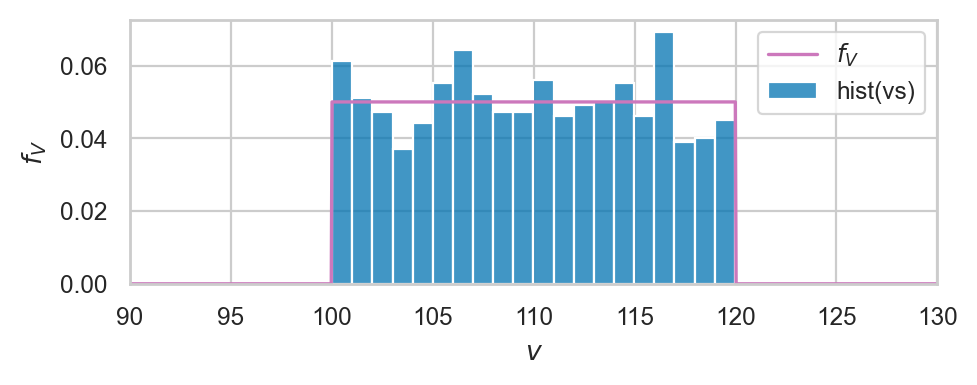

In [41]:
# a) Plot histogram of `vs`
import seaborn as sns
ax = sns.histplot(x=vs, stat="density", bins=20, label="hist(vs)")

# Plot the PDF of rvV
from scipy.stats import uniform
rvV = uniform(100, 120-100)
from ministats import plot_pdf
plot_pdf(rvV, ax=ax, xlims=[90,130], rv_name="V", color="C4", label="$f_V$");
ax.set_xlim(90,130)

# FIGURES ONLY
from ministats.utils import savefigure
filename = "figures/statsprobsfigs/prob/generate_vsample_and_pdf_rvV.pdf"
savefigure(ax, filename)

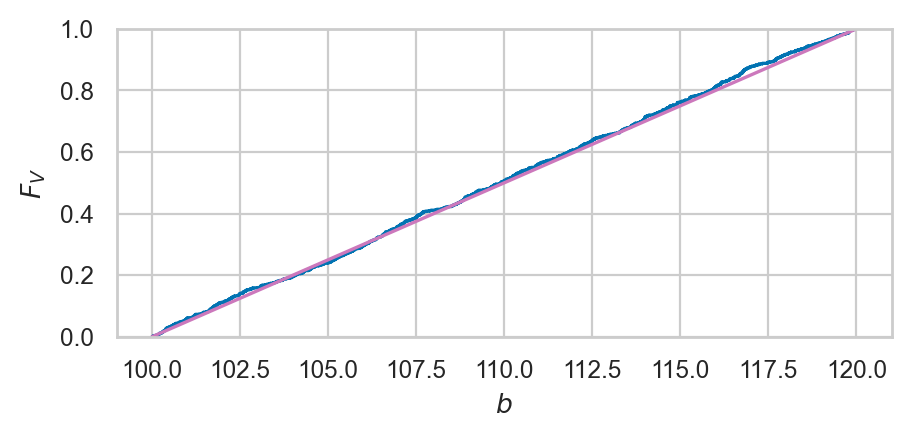

In [42]:
# b) Inspect the empirical CDF of the `vs` and the CDF of `rvV`

# Plot the eCDF of the `us`
ax = sns.ecdfplot(x=vs)

# Plot the CDF of `rvU`
from ministats import plot_cdf
plot_cdf(rvV, ax=ax, rv_name="V", color="C4");

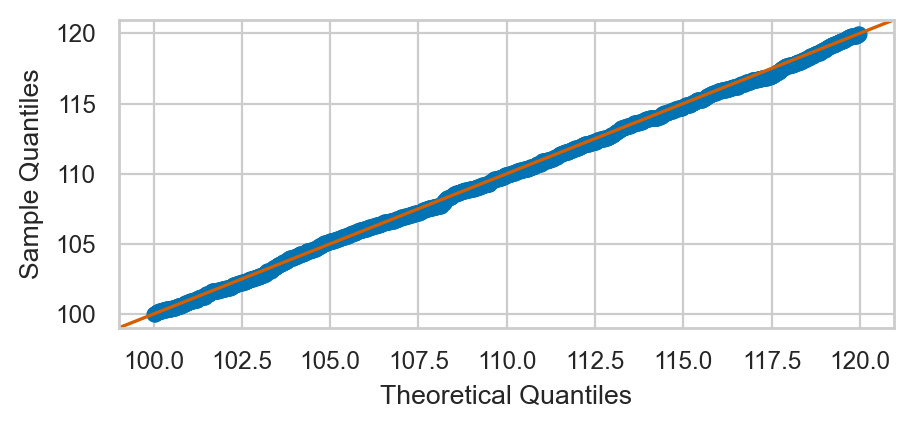

In [43]:
# c) Generate a Q-Q plot of the `vs` versus `rvV`

# Wrap the data `vs` as a NumPy array
vs_array = np.array(vs)

# Generate the Q-Q plot
import statsmodels.api as sm
sm.qqplot(vs_array, rvV, line="45");

In [44]:
# d) Compare the variance, the skew, and the kurtosis of the `vs` and `rvV`

# Wrap the data `vs` as a pandas series object
vs_series = pd.Series(vs)

# Compare the mean of the `vs` and `rvV`
vs_series.mean(), rvV.mean()

(109.85360803996666, 110.0)

In [45]:
# d) Compare the variance of the `vs` and `rvV`
vs_series.var(),  rvV.var()

(32.712319248794365, 33.33333333333333)

In [46]:
# d) Compare the skew of the `vs` and `rvV`
vs_series.skew(), rvV.stats("s")

(-0.0057431543657164566, 0.0)

In [47]:
# d) Compare the kurtosis of the `vs` and `rvV`
vs_series.kurt(), rvV.stats("k")

(-1.1732315891226595, -1.2)

In [48]:
# e) Compute the Kolmogorov--Smirnov distance between `vs` and `rvV`
from scipy.stats import ks_1samp
ks_1samp(vs, rvV.cdf).statistic

0.0276402879346046

### E2.55

Repeat the steps in
to compare random values generated by the computer model `scipy.stats.t`
for Student's $t$-distribution with $\nu=7$ degrees of freedom $T \sim \mathcal{T}(\nu\!=\!7)$.
Start by alias-importing `scipy.stats.t` as `tdist`,
creating the computer model `rvT = tdist(df=7)`,
and generating a list of $N=500$ random observations using `ts = rvT.rvs(500)`.

**a)** Plot a histogram of the observations `ts` and the PDF $f_T$.

**b)** Plot the empirical CDF $F_{\texttt{ts}}$ and the CDF $F_T$.

**c)** Generate a Q-Q plot of `ts` versus $T$.

**d)** Compute the mean, the variance, the skew, and the excess kurtosis of the data `ts`
and compare them to the properties of $T$.

**e)** Compute the Kolmogorov--Smirnov distance $D_{\textrm{KS}}(\texttt{ts},T)$.


In [50]:
# Create the computer model for `rvT`
from scipy.stats import t as tdist
rvT = tdist(df=7)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(50)

# Generate 500 observations from rvT
ts = rvT.rvs(500)

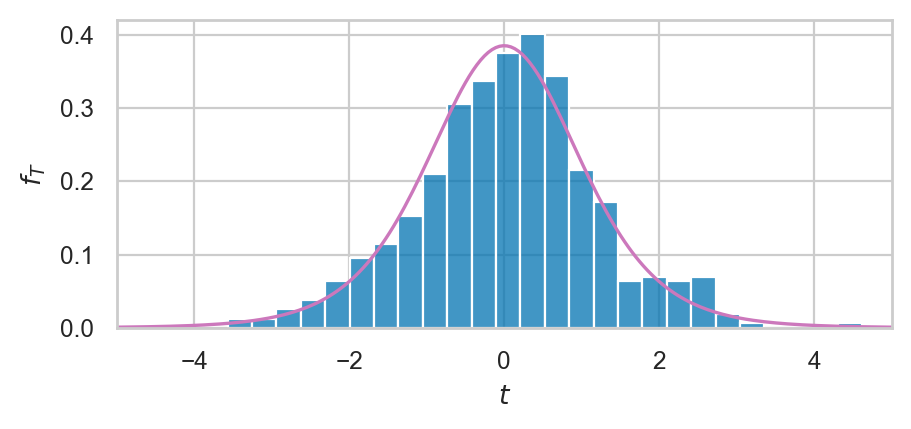

In [51]:
# a) Plot histogram of `ts`
import seaborn as sns
ax = sns.histplot(x=ts, stat="density", bins=30)

# Plot the PDF of rvT
from ministats import plot_pdf
plot_pdf(rvT, ax=ax, rv_name="T", color="C4")
ax.set_xlim(-5,5);

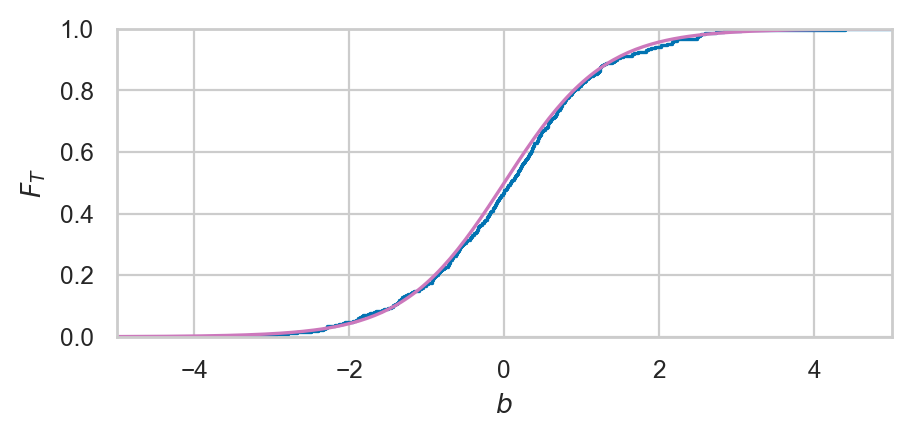

In [52]:
# b) Inspect the empirical CDF of the `ts` and the CDF of `rvT`

# Plot the eCDF of the `ts`
ax = sns.ecdfplot(x=ts)

# Plot the CDF of `rvT`
from ministats import plot_cdf
plot_cdf(rvT, ax=ax, rv_name="T", color="C4");
ax.set_xlim(-5,5);

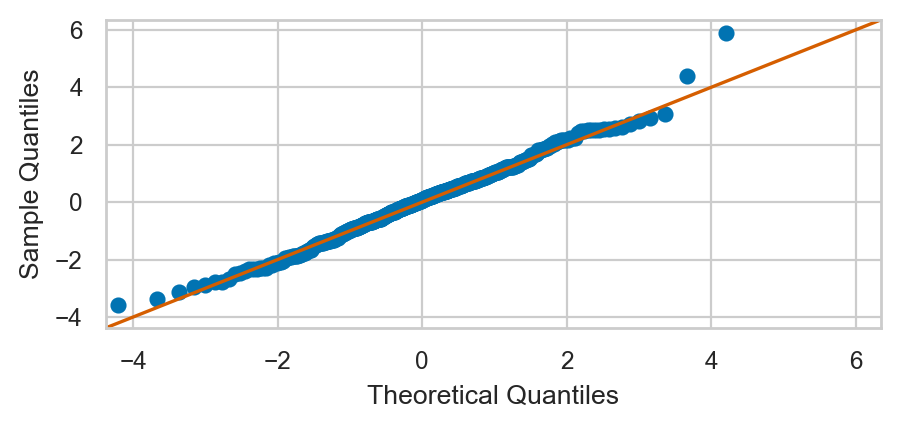

In [53]:
# c) Generate a Q-Q plot of the `ts` versus `rvT`

# Wrap the data `ts` as a NumPy array
ts_array = np.array(ts)

# Generate the Q-Q plot
import statsmodels.api as sm
sm.qqplot(ts_array, rvT, line="45");

In [54]:
# d) Compare the variance, the skew, and the kurtosis of the `ts` and `rvT`

# Wrap the data `ts` as a pandas series object
ts_series = pd.Series(ts)

# Compare the mean of the `ts` and `rvT`
ts_series.mean(), rvT.mean()

(0.04689981130168986, 0.0)

In [55]:
# d) Compare the variance of the `ts` and `rvT`
ts_series.var(),  rvT.var()

(1.4260985559274129, 1.4)

In [56]:
# d) Compare the skew of the `ts` and `rvT`
ts_series.skew(), rvT.stats("s")

(0.17470441996790062, 0.0)

In [57]:
# d) Compare the kurtosis of the `ts` and `rvT`
ts_series.kurt(), rvT.stats("k")

(1.2602680965343773, 2.0)

In [58]:
# d) ALT. using `scipy.stats.kurtosis` with the options `bias=False` and `fisher=True`
from scipy.stats import kurtosis
kurtosis(ts, bias=False, fisher=True)

1.2602680965343769

In [59]:
# e) Compute the Kolmogorov--Smirnov distance between `ts` and `rvT`
from scipy.stats import ks_1samp
ks_1samp(ts, rvT.cdf).statistic

0.037384815434187146